In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")

base = Path.cwd()
root = base if (base / "data").exists() else base.parent

matches = pd.read_csv(root / "data" / "processed" / "matches_clean.csv", parse_dates=["Date"])

fig_dir = root / "images"
fig_dir.mkdir(exist_ok=True)

print(matches.shape)
matches.head()

(1900, 23)


,Season,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HS,AS,HST,...,HC,AC,HY,AY,HR,AR,TotalGoals,GoalDiff,Result,Target
0,2021-22,2021-08-13,Brentford,Arsenal,2,0,H,8,22,3,...,2,5,0,0,0,0,2,2,Home Win,0
1,2021-22,2021-08-14,Man United,Leeds,5,1,H,16,10,8,...,5,4,1,2,0,0,6,4,Home Win,0
2,2021-22,2021-08-14,Burnley,Brighton,1,2,A,14,14,3,...,7,6,2,1,0,0,3,-1,Away Win,2
3,2021-22,2021-08-14,Chelsea,Crystal Palace,3,0,H,13,4,6,...,5,2,0,0,0,0,3,3,Home Win,0
4,2021-22,2021-08-14,Everton,Southampton,3,1,H,14,6,6,...,6,8,2,0,0,0,4,2,Home Win,0


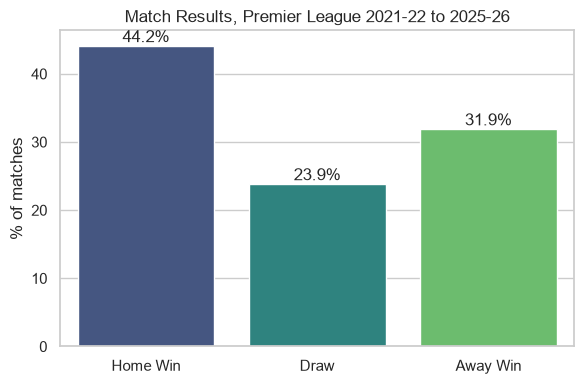

In [2]:
order = ["Home Win", "Draw", "Away Win"]
pct = matches["Result"].value_counts(normalize=True).reindex(order) * 100

plt.figure(figsize=(6, 4))
ax = sns.barplot(x=pct.index, y=pct.values, hue=pct.index, palette="viridis", legend=False)
for i, v in enumerate(pct.values):
    ax.text(i, v + 0.5, f"{v:.1f}%", ha="center")
plt.title("Match Results, Premier League 2021-22 to 2025-26")
plt.ylabel("% of matches")
plt.xlabel("")
plt.tight_layout()
plt.savefig(fig_dir / "01_result_distribution.png", dpi=150)
plt.show()